In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, HDBSCAN, KMeans
from kmedoids import KMedoids
from sklearn.metrics import adjusted_rand_score

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, benchmark_functional_groups, evaluate_hdbscan_grid

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["onehot"])
df = qm9.load()
molecules = qm9.get_molecules()
X = np.array(df['selfies_onehot'].to_list())

2026-04-27 19:11:47.402 | INFO     | src.datasets:load:864 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-27 19:11:47.803 | INFO     | src.datasets:_sample_qm9_df:1064 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-27 19:11:47.804 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-27 19:11:47.804 | INFO     | src.features:compute_selfies_onehot:265 - Computing One-Hot Encodings...
2026-04-27 19:11:48.732 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['selfies_onehot']
2026-04-27 19:11:49.479 | SUCCESS  | src.datasets:get_molecules:1676 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [4]:
ls_selfies = np.array(df['selfies_onehot'].to_list())
ls_selfies[0]

array([0, 0, 0, ..., 0, 0, 1], shape=(2795,))

In [5]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,selfies_onehot
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i64]
"""qm9_21""","""C3H8O""","""[H]OC([H])(C([H])([H])[H])C([H…","""[H]OC([H])(C([H])([H])[H])C([H…","""Acyclic""","""Acyclic""","""Acyclic""","""[4*]C([H])(C([H])([H])[H])C([H…","""""","""[H][O][C][Branch1][C][H][Branc…","""alcohol""","""Acyclic""",0,null,60,0,20,0.940086,13.015533,4,0,0,0,1,12,1.833333,3,0.0,0.0,1.0,1,1,3,0,0,3,4,24,1.199232,0,1,0,0,0,0,0,0,0,0,"[[-0.0332, 1.5478, -0.0044], [-0.0111, 0.0186, 0.0168], … [-1.8182, -0.1558, -0.6955]]","[6, 6, … 1]",1.4259,38.580002,-7.107614,2.013643,9.118535,318.372101,2.929931,-5286.280273,-5286.131348,-5286.105469,-5287.026855,19.052,-45.175072,-45.4883,-45.77108,-42.007965,8.67553,8.00568,4.75542,"[0, 0, … 1]"
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",0,null,58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,0,0,0,0,0,0,0,0,0,0,"[[0.1688, 1.5251, -0.1575], [-0.1874, 0.0619, 0.1468], … [0.3538, 0.2066, 2.2887]]","[6, 6, … 1]",2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,"[0, 0, … 1]"
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""","""Aliphatic Ring""",0,null,71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,"[[0.0005, 0.0067, -0.0974], [-0.0137, 1.1921, 0.0314], … [1.5674, 2.4713, -0.8115]]","[8, 6, … 1]",2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 1]"
"""qm9_92""","""C4H8O""","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H]C1([H])O[C@@]([H])(C([H])([…","""C1COC1""","""C1CCC1""","""*1***1""","""[8*]C([H])([H])[H],[13*][C@]1(…","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H][C][Branch1][C][H][O][C@@][…","""ether""","""Aliphatic Ring""",0,null,72,0,9,0.964858,12.880514,5,1,0,0,1,13,2.0,1,0.0,0.0,1.0,0,1,4,0,0,4,5,27,1.243901,0,0,0,0,0,0,0,0,1,0,"[[-0.3231, 1.5375, 0.0195], [0.1185, 0.089, -0.0052], … [2.9697, -0.3692, -0.4041]]","[6, 6, … 1]",1.6826,45.720001,-6.557944,2.489842,9.047786,407.690887,3.118153,-6322.054688,-6321.90918,-6321.883301,-6322.826172,18.582001,-51.086094,-51.441444,-51.749908,-47.548447,9.93129,4.56362,3.63704,"[0, 0, … 1]"
"""qm9_203""","""C4H5NO""","""[H]OC1=C([H])N([H])C([H])=C1[H…","""[H]Oc1c([H])c([H])n([H])c1[H]""","""c1cc[nH]c1""","""C1CCCC1""","""*1:*:*:*:*:1""","""[16*]c1c([H])c([H])n([

In [6]:
len(molecules[0:2])

2

In [7]:
plot_molecules_with_py3dmol(molecules[0:4])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
dist_type = "tanimoto"
dist_matrix = qm9.get_distance_matrix(
    descriptor="onehot",
    dist_type=dist_type,
    force_calculate=True
)

2026-04-27 19:11:50.780 | INFO     | src.datasets:get_distance_matrix:1487 - Calculating distance matrix for selfies_onehot using jaccard distance.
2026-04-27 19:12:16.390 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_selfies_onehot_jaccard.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:08<00:00,  1.18it/s]


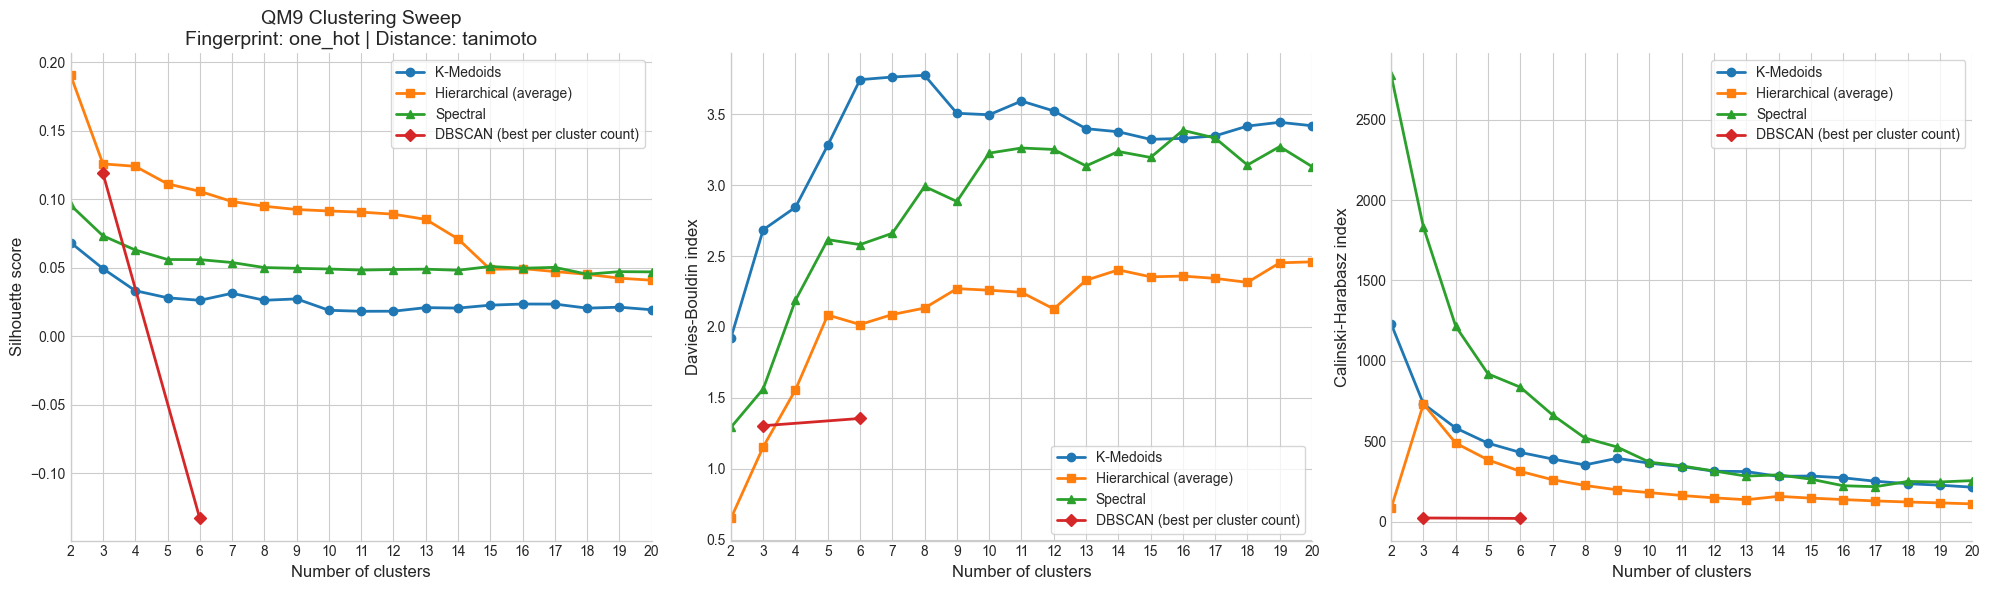

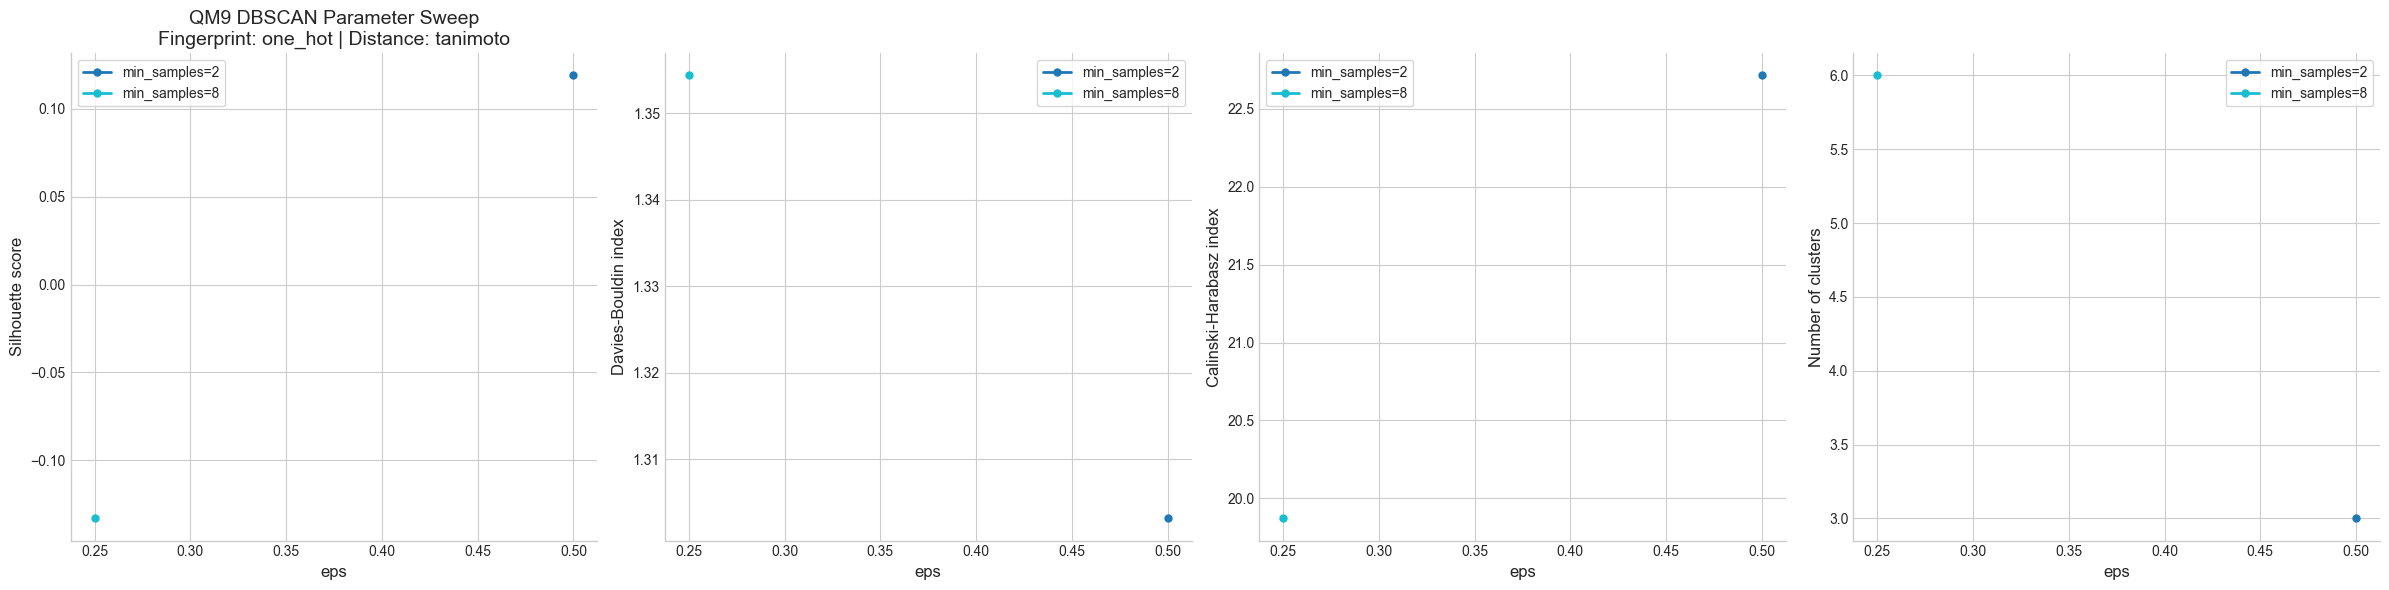

2026-04-27 19:13:21.696 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:985 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/one_hot/clustering_sweep_2_to_20_clusters.png
2026-04-27 19:13:21.696 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/one_hot/dbscan_parameter_sweep.png
2026-04-27 19:13:21.697 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:988 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/one_hot/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    dataset_name="qm9",
)

In [10]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(446), np.int64(447)), (np.int64(996), np.int64(4831)), (np.int64(2499), np.int64(2500)), (np.int64(2502), np.int64(2503)), (np.int64(4184), np.int64(4185)), (np.int64(1912), np.int64(1913)), (np.int64(3813), np.int64(3814)), (np.int64(3271), np.int64(3272)), (np.int64(4556), np.int64(4558)), (np.int64(1369), np.int64(1370))]


In [11]:
print(mols[0])

(Atoms(symbols='C4OC3H12', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='C4ONC2H11', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_51860/2616862307.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2, 3, 4, 5], dtype=int32), array([1562, 2079, 1089,    8,  262]))


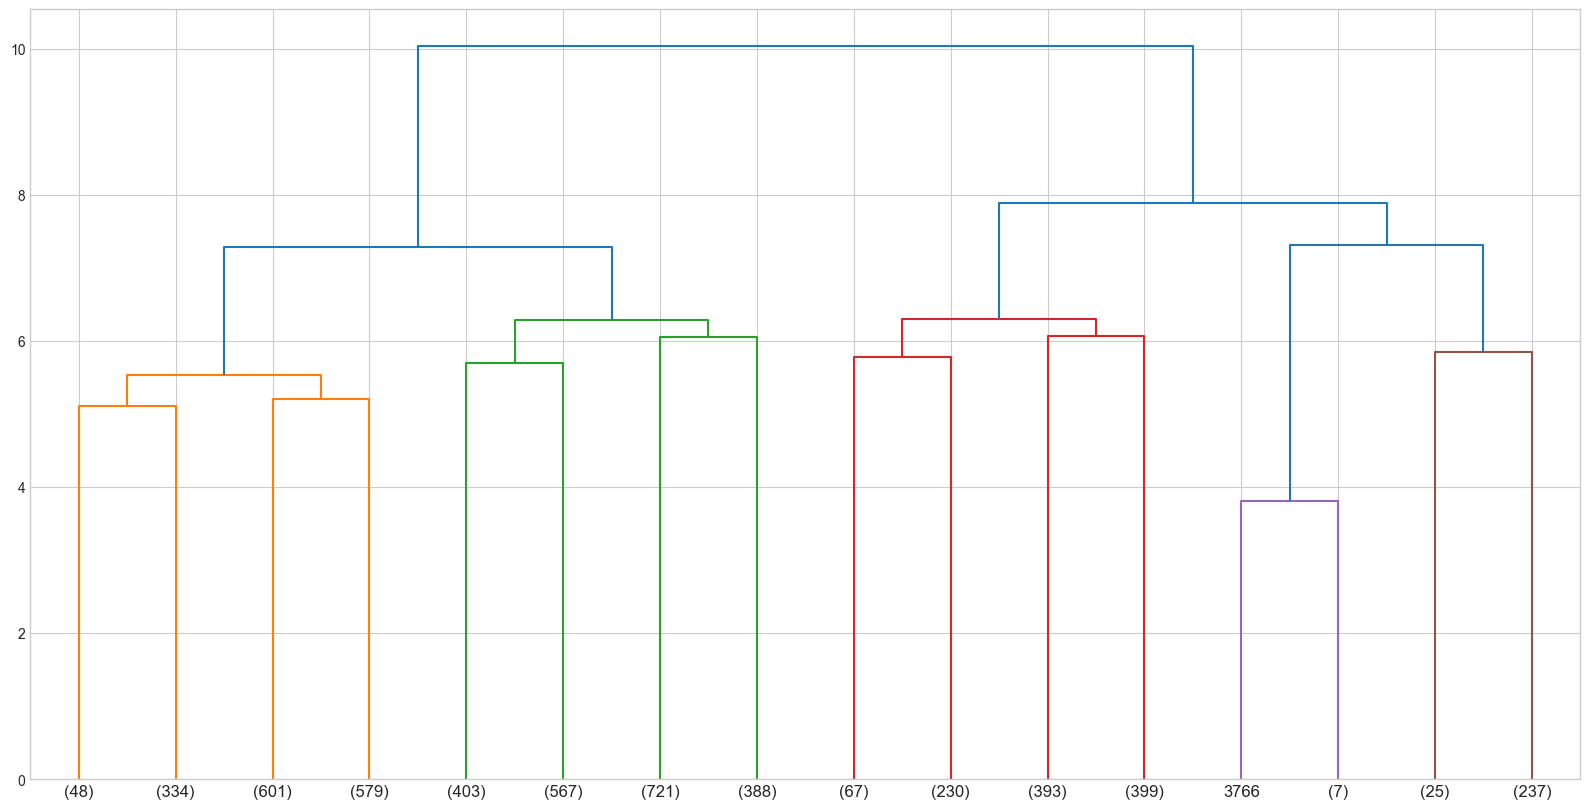

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=3, truncate_mode='level')
labels_hier = fcluster(link, t=7, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

2026-04-27 19:13:40.075 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:13:40.076 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:14:02.803 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:14:02.808 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:14:03.057 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:14:03.127 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

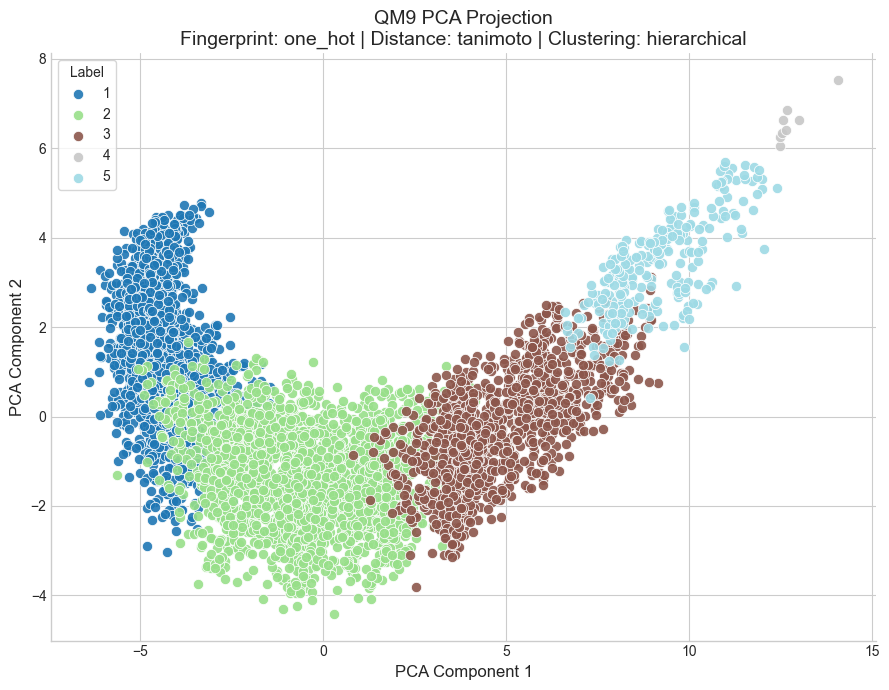

2026-04-27 19:14:03.749 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png


{'coords': array([[-5.60745462,  1.4015037 ],
        [-5.61246276,  3.38903767],
        [-5.05969243,  2.23594487],
        ...,
        [-1.62225685, -1.64970579],
        [-5.76115234,  0.23034785],
        [-4.67063778, -2.31152602]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'hierarchical'}

In [15]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [16]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (5, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬─────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

- Clustering on unique selfies string and patterns - such as unique branching and number of atoms

In [17]:
ari_score = adjusted_rand_score(df["generic_scaffold"], df["labels_hier"])
print(f"ARI score: {ari_score} ")

ARI score: 0.014431949866576537 


In [18]:
benchmark_functional_groups(df, "labels_hier")

[{'Cluster': 1,
  'Size': 1562,
  'Top_FG_1': 'fr_ether (36.2%)',
  'Top_FG_2': 'fr_alcohol (22.8%)',
  'Top_FG_3': 'fr_amine (18.4%)'},
 {'Cluster': 2,
  'Size': 2079,
  'Top_FG_1': 'fr_ether (49.7%)',
  'Top_FG_2': 'fr_alcohol (34.4%)',
  'Top_FG_3': 'fr_ketone (14.3%)'},
 {'Cluster': 3,
  'Size': 1089,
  'Top_FG_1': 'fr_ether (46.8%)',
  'Top_FG_2': 'fr_alcohol (33.5%)',
  'Top_FG_3': 'fr_amine (9.5%)'},
 {'Cluster': 4,
  'Size': 8,
  'Top_FG_1': 'fr_benzene (0.0%)',
  'Top_FG_2': 'fr_alcohol (0.0%)',
  'Top_FG_3': 'fr_phenol (0.0%)'},
 {'Cluster': 5,
  'Size': 262,
  'Top_FG_1': 'fr_ether (42.4%)',
  'Top_FG_2': 'fr_alcohol (9.2%)',
  'Top_FG_3': 'fr_amine (4.6%)'}]

# KMedoids

In [19]:
model_km = KMedoids(n_clusters=2, metric="precomputed", random_state=42)
labels_km = model_km.fit_predict(dist_matrix)
medoid_indices = model_km.medoid_indices_
print(medoid_indices)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)
medoids_df = df[medoid_indices]
print(medoids_df.select(["labels_km", "mol_id", "smiles", "scaffold_smiles"]))

[ 86 111]
(array([0, 1], dtype=uint64), array([2387, 2613]))
shape: (2, 4)
┌───────────┬──────────┬─────────────────────────────────┬─────────────────┐
│ labels_km ┆ mol_id   ┆ smiles                          ┆ scaffold_smiles │
│ ---       ┆ ---      ┆ ---                             ┆ ---             │
│ u64       ┆ str      ┆ str                             ┆ str             │
╞═══════════╪══════════╪═════════════════════════════════╪═════════════════╡
│ 0         ┆ qm9_2056 ┆ [H]OC1([H])C([H])([H])C([H])([… ┆ C1CCCCC1        │
│ 1         ┆ qm9_2617 ┆ [H]C(=O)C#CC([H])([H])C([H])([… ┆ Acyclic         │
└───────────┴──────────┴─────────────────────────────────┴─────────────────┘


In [20]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-27 19:14:04.330 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:14:04.331 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:14:26.515 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:14:26.518 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:14:26.777 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:14:26.845 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

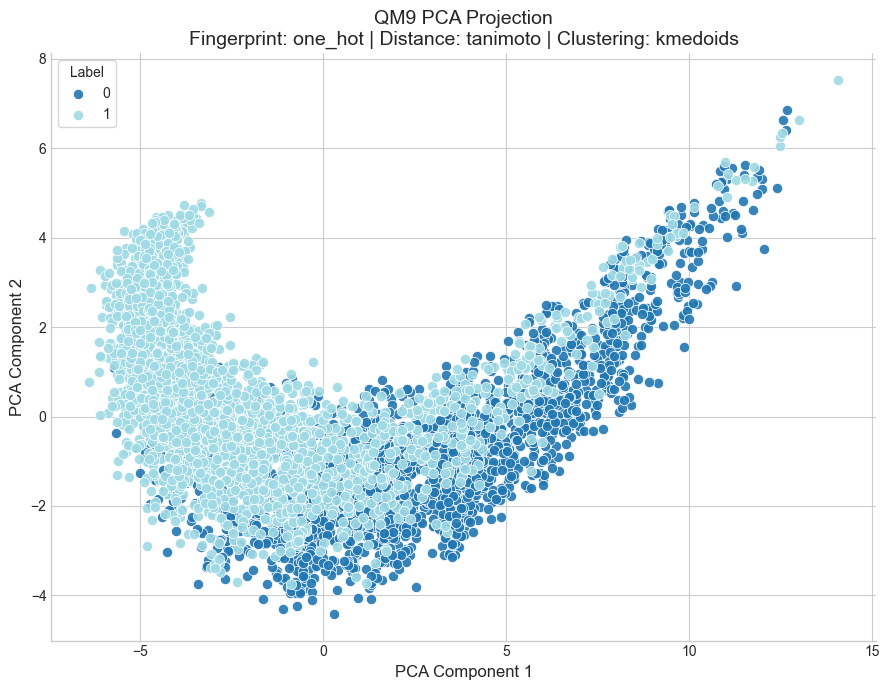

2026-04-27 19:14:27.866 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_kmedoids_projection.png


{'coords': array([[-5.60745462,  1.4015037 ],
        [-5.61246276,  3.38903767],
        [-5.05969243,  2.23594487],
        ...,
        [-1.62225685, -1.64970579],
        [-5.76115234,  0.23034785],
        [-4.67063778, -2.31152602]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'kmedoids'}

In [21]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [22]:
average_numeric_by_cluster(df, "labels_km")

shape: (2, 72)
┌───────────┬───────┬─────────────────┬─────────────┬────────────┬────────┬─────────┬─────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,2387,2.138039,0.0,124.343527,0.121491,30.713029,0.896445,12.846392,8.847088,1.809384,0.035191,0.004189,2.081693,20.10641,2.07245,2.709258,0.02945,0.118127,0.852423,0.976121,1.699623,7.092166,0.206116,0.778802,5.780478,6.426477,43.084625,1.259839,0.000838,0.457478,0.005027,0.099288,0.101382,0.000838,0.027231,0.11437,0.556766,0.0,2.379518,77.98814,-6.501755,0.787324,7.289008,1232.165029,4.577966,-11056.138856,-11055.898309,-11055.872595,-11057.056817,33.257322,-81.620333,-82.139562,-82.620566,-75.861621,3.158116,1.361481,1.116047,2.600754,86.803519,3.519062,9.677419,43.084625,884,"""Acyclic""",9.677419,244,"""C1CC1""",11.101801,1,null,0.0
1,2613,1.96625,0.0,121.227325,0.025258,41.960964,0.824197,12.858486,8.717949,1.515882,0.305779,0.044776,2.792576,16.652889,2.051171,1.899349,0.102138,0.328997,0.568865,0.864524,2.310754,5.936089,0.655568,1.747799,3.522005,6.289705,33.083812,1.264916,0.004975,0.242633,0.049369,0.17145,0.125144,0.002296,0.046307,0.128971,0.499809,0.002296,2.95056,72.579089,-6.570639,-0.154319,6.416319,1152.144052,3.566294,-11280.265795,-11280.043277,-11280.017581,-11281.168181,30.147739,-70.887549,-71.298491,-71.695216,-66.068029,240.938633,1.429022,1.11754,1.577114,60.084194,29.161883,10.753923,33.083812,929,"""Acyclic""",10.753923,220,"""C1CCCC1""",18.40796,1,null,0.0


In [23]:
benchmark_functional_groups(df, "labels_km")

[{'Cluster': 0,
  'Size': 2387,
  'Top_FG_1': 'fr_ether (47.8%)',
  'Top_FG_2': 'fr_alcohol (38.8%)',
  'Top_FG_3': 'fr_ketone (11.0%)'},
 {'Cluster': 1,
  'Size': 2613,
  'Top_FG_1': 'fr_ether (41.3%)',
  'Top_FG_2': 'fr_alcohol (20.5%)',
  'Top_FG_3': 'fr_amine (15.6%)'}]

# Spectral

In [24]:
# model_spectral = SpectralClustering(
#                 n_clusters=3,
#                 affinity="precomputed",
#                 assign_labels='kmeans',
#                 random_state=42,
#             )

# labels_spectral = model_spectral.fit_predict(dist_matrix)
# df = df.with_columns(labels_spectral=labels_spectral)
# # print(np.unique(labels_spectral, return_counts=True))

In [25]:
# create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [26]:
# plot_distance_matrix_projection(
#     dist_matrix=dist_matrix,
#     fingerprint="one_hot",
#     distance_metric=dist_type,
#     projection_method="PCA",
#     dataset_name="qm9",
#     labels=labels_spectral,
#     clustering_method="spectral"
# )

In [27]:
# average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN 

In [28]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=4,
    metric='precomputed'
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([ 382, 4569,    4,    6,    6,    5,    9,    4,    4,    3,    4,
          4]))


In [29]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-04-27 19:14:29.364 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:14:29.365 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:14:51.584 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:14:51.587 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:14:52.295 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:14:52.366 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

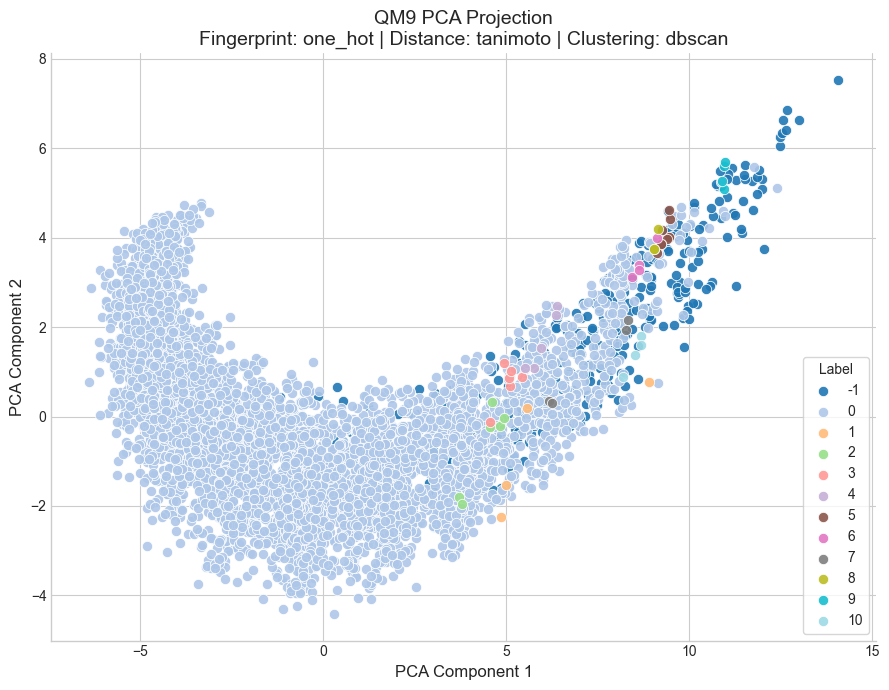

2026-04-27 19:14:53.078 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png


{'coords': array([[-5.60745462,  1.4015037 ],
        [-5.61246276,  3.38903767],
        [-5.05969243,  2.23594487],
        ...,
        [-1.62225685, -1.64970579],
        [-5.76115234,  0.23034785],
        [-4.67063778, -2.31152602]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'dbscan'}

In [30]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [31]:
average_numeric_by_cluster(df, "labels_db")

shape: (12, 73)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬───────────┬───────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,382,2.228006,0.0,125.094241,0.544503,19.641361,0.88701,12.831939,8.950262,2.099476,0.020942,0.0,1.421466,22.232984,2.094127,3.010471,0.015603,0.053169,0.931228,0.842932,1.02356,7.973822,0.117801,0.39267,7.018325,6.486911,49.54712,1.257858,0.0,0.277487,0.0,0.133508,0.02356,0.0,0.002618,0.036649,0.405759,0.0,1.642651,83.604424,-6.469172,1.446941,7.91602,1293.94159,5.185045,-10563.08615,-10562.837004,-10562.811337,-10564.010354,35.054034,-88.596388,-89.182958,-89.714601,-82.269507,3.035653,1.311201,1.104815,3.554974,0.230366,87.958115,2.094241,9.947644,49.54712,224,"""Acyclic""",9.947644,96,"""Acyclic""",9.947644,1,null,0.0
0,4569,2.031291,0.0,122.488947,0.027358,38.248632,0.855969,12.854654,8.763406,1.613263,0.191508,0.027796,2.551762,17.926242,2.058239,2.214927,0.072274,0.245133,0.682592,0.925367,2.11578,6.346684,0.471,1.371635,4.369009,6.340775,36.74524,1.262957,0.003283,0.352594,0.03086,0.137448,0.121909,0.001751,0.04049,0.130225,0.538411,0.001313,2.778116,74.352729,-6.545785,0.185239,6.730992,1180.575846,3.941848,-11231.681688,-11231.452295,-11231.426587,-11232.590134,31.30667,-74.820341,-75.271274,-75.699271,-69.652673,139.158748,1.404236,1.117983,1.922521,0.549792,71.459838,18.340994,10.199168,36.74524,1418,"""Acyclic""",10.199168,302,"""C1CCCC1""",13.832348,1,null,0.0
1,4,2.142273,0.0,124.75,0.5,29.0,0.931501,12.96887,8.5,0.0,0.0,0.0,2.25,22.75,1.911818,6.75,0.0,0.041667,0.958333,0.75,2.0,6.5,0.0,0.25,6.0,8.0,48.75,1.223936,0.0,0.75,0.0,0.0,0.25,0.0,0.0,0.0,1.0,0.0,2.13915,80.055,-6.729375,2.016364,8.74642,1698.422455,5.535272,-11175.989502,-11175.688477,-11175.663086,-11177.004883,38.364,-88.81012,-89.385706,-89.944799,-82.304497,3.516308,0.835507,0.710355,3.0,0.25,0.0,0.0,100.0,48.75,1,"""Acyclic""",100.0,1,"""Acyclic""",100.0,1,null,0.0
2,6,2.059289,0.0,127.0,0.833333,20.0,0.925915,12.841175,9.0,0.333333,0.0,0.0,1.5,22.666667,1.942029,4.833333,0.166667,0.047619,0.785714,0.833333,1.5,6.5,1.333333,0.333333,5.833333,7.5,46.666667,1.231075,0.0,0.166667,0.0,0.0,0.0,0.0,0.0,0.0,0.666667,0.0,0.9166,86.969999,-6.762483,0.956934,7.71987,1615.572286,5.210191,-10868.447917,-10868.158203,-10868.132487,-10869.433594,38.906,-89.356634,-89.914628,-90.454413,-82.994333,3.10335,0.971833,0.779792,3.0,0.333333,33.333333,0.0,66.666667,46.666667,3,"""Acyclic""",66.666667,2,"""Acyclic""",66.666667,1,null,0.0
3,6,2.248413,0.0,124.5,-0.166667,17.5,0.896019,12.786814,9.0,3.166667,0.0,0.0,1.5,20.833333,2.20873,1.666667,0.0,0.0,1.0,1.333333,0.833333,8.166667,0.0,0.0,7.5,5.833333,46.833333,1.278181,0.0,0.666667,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.0,1.737183,79.531667,-6.003739,1.612728,7.616467,999.61673,4.673977,-10649.382487,-10649.168783,-10649.142904,-10650.246582,32.0065,-83.287167,-83.844112,-84.332466,-77.382057,2.475248,1.849822,1.481462,3.0,0.5,100.0,0.0,0.0,46.833333,6,"""C1C[NH+]2CC3C1C32""",16.666

# HDBSCAN

In [32]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=300, ms=1, clusters=2, noise=0.45, persistence=0.046, score=0.026
mcs=80, ms=1, clusters=3, noise=0.03, persistence=0.020, score=0.019
mcs=220, ms=1, clusters=2, noise=0.29, persistence=0.024, score=0.017
mcs=300, ms=10, clusters=2, noise=0.26, persistence=0.017, score=0.013
mcs=220, ms=10, clusters=2, noise=0.18, persistence=0.014, score=0.012
mcs=220, ms=22, clusters=2, noise=0.19, persistence=0.013, score=0.011
mcs=300, ms=30, clusters=2, noise=0.24, persistence=0.014, score=0.011
mcs=300, ms=300, clusters=4, noise=0.42, persistence=0.017, score=0.010
mcs=220, ms=40, clusters=2, noise=0.23, persistence=0.013, score=0.010
mcs=220, ms=55, clusters=2, noise=0.22, persistence=0.012, score=0.010
mcs=300, ms=40, clusters=2, noise=0.31, persistence=0.014, score=0.010
mcs=150, ms=75, clusters=2, noise=0.16, persistence=0.010, score=0.009
mcs=120, ms=1, clusters=4, noise=0.17, persistence=0.010, score=0.009
mcs=150, ms=1, clusters=4, noise=0.17, persistence=0.010, s

In [45]:
hdbscan = HDBSCAN(min_cluster_size=300, min_samples=10, metric='precomputed')
labels_hdbscan = hdbscan.fit_predict(dist_matrix.astype(np.float64))
df= df.with_columns(labels_hdbscan=labels_hdbscan)
print(np.unique(labels_hdbscan, return_counts=True))

/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


(array([-1,  0,  1]), array([1159, 3508,  333]))


In [46]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-04-27 19:19:11.989 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:19:11.990 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:19:36.147 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:19:36.151 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:19:36.418 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:19:36.491 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [35]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (10, 74)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,331,2.241118,0.0,123.984894,0.703927,15.314199,0.89359,12.815522,8.900302,2.141994,0.006042,0.0,1.193353,22.425982,2.098879,2.809668,0.016287,0.042091,0.941622,0.694864,0.791541,8.075529,0.132931,0.320242,7.253776,6.302115,50.244713,1.258397,0.0,0.196375,0.0,0.087613,0.02719,0.0,0.003021,0.024169,0.338369,0.0,1.493919,84.115921,-6.484695,1.499117,7.983673,1257.492618,5.268543,-10329.727507,-10329.481438,-10329.455738,-10330.645229,34.909746,-89.502135,-90.100351,-90.637733,-83.112115,2.980672,1.383274,1.162181,3.688822,0.296073,-0.332326,89.425982,0.60423,9.969789,50.244713,191,"""Acyclic""",9.969789,111,"""C1CC1""",11.480363,1,null,0.0
0,40,2.24751,0.0,126.25,0.875,13.475,0.910751,12.82978,9.0,2.0,0.0,0.0,1.1,23.6,2.079923,3.85,0.0,0.016865,0.983135,0.675,0.75,8.275,0.0,0.125,7.775,6.8,53.0,1.254189,0.0,0.3,0.0,0.125,0.0,0.0,0.0,0.0,0.425,0.0,1.171593,86.7415,-6.50427,1.875749,8.380358,1357.096791,5.589091,-10457.84292,-10457.580566,-10457.55481,-10458.778784,36.764925,-93.118645,-93.743751,-94.309898,-86.413465,2.793236,1.245936,1.03862,4.45,0.1,0.825,90.0,0.0,10.0,53.0,26,"""C1CC2CC12""",10.0,20,"""C1CC1""",15.0,1,null,0.0
1,47,2.228547,0.0,127.021277,0.468085,19.978723,0.888381,12.867275,9.0,1.851064,0.0,0.0,1.553191,23.042553,2.070617,3.255319,0.0,0.035419,0.964581,0.851064,1.148936,8.06383,0.0,0.276596,7.170213,6.914894,51.319149,1.25284,0.0,0.234043,0.0,0.191489,0.021277,0.0,0.0,0.021277,0.659574,0.0,1.697709,84.621489,-6.418992,1.628051,8.046812,1377.999736,5.38898,-10769.974651,-10769.71848,-10769.692715,-10770.910987,35.624426,-90.481494,-91.086229,-91.634771,-83.969471,3.027612,1.225055,1.007193,3.723404,0.170213,0.255319,91.489362,0.0,8.510638,51.319149,40,"""C1CC1""",8.510638,28,"""C1CC1""",10.638298,1,null,0.0
2,93,2.213499,0.0,126.634409,0.494624,20.677419,0.89209,12.854513,9.0,1.88172,0.0,0.0,1.537634,22.688172,2.065537,3.526882,0.010539,0.04683,0.942631,0.83871,1.139785,7.903226,0.086022,0.365591,7.010753,6.677419,50.193548,1.253109,0.0,0.311828,0.0,0.107527,0.021505,0.0,0.0,0.053763,0.516129,0.0,1.858919,84.194516,-6.379548,1.47395,7.853206,1321.544426,5.312969,-10759.271579,-10759.012317,-10758.986612,-10760.206055,36.083581,-89.977454,-90.571532,-91.114915,-83.522058,2.768521,1.280553,1.061326,3.591398,0.150538,-0.021505,87.096774,0.0,12.903226,50.193548,60,"""Acyclic""",12.903226,33,"""Acyclic""",12.903226,1,null,0.0
3,119,2.20659,0.0,126.605042,0.184874,22.621849,0.881371,12.860398,9.0,2.109244,0.008403,0.0,1.773109,21.97479,2.083122,3.210084,0.009704,0.070395,0.919901,0.941176,1.235294,7.798319,0.067227,0.512605,6.647059,6.714286,48.462185,1.254919,0.0,0.310924,0.0,0.151261,0.042017,0.0,0.0,0.033613,0.596639,0.0,1.937781,82.446975,-6.396528,1.228514,7.624996,1317.19797,5.025535,-10909.954003,-10909.705144,-10909.679392,-10910.881573,34.652395,-86.

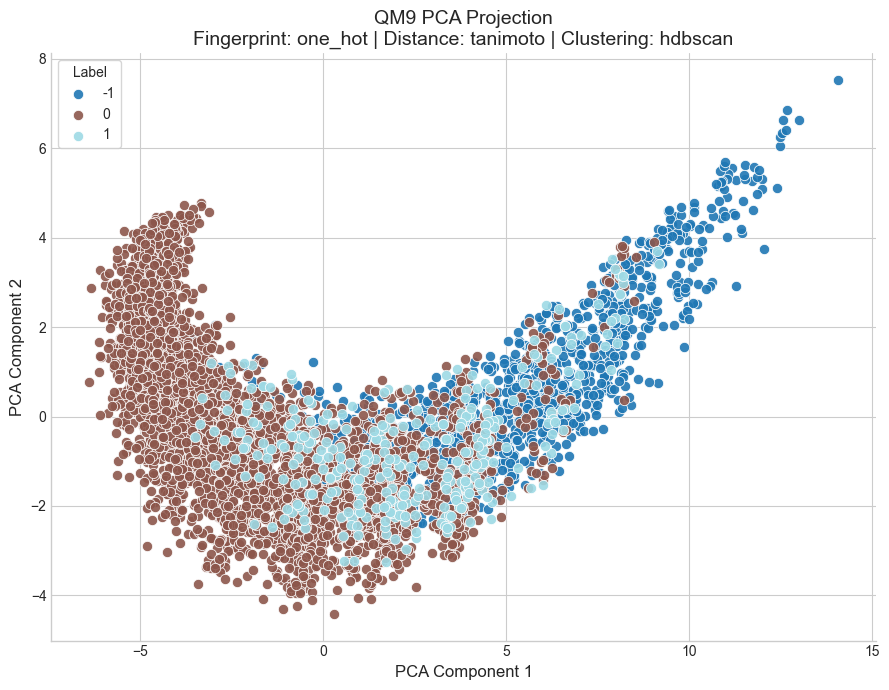

2026-04-27 19:19:38.251 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_hdbscan_projection.png


In [47]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

# KMeans

In [37]:
kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df= df.with_columns(kmeans_labels=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([1313, 1636, 2051]))


In [38]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

2026-04-27 19:15:53.936 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:15:53.940 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:16:18.530 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:16:18.535 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:16:18.779 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:16:18.849 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [39]:
average_numeric_by_cluster(df, "kmeans_labels")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

kmeans_labels,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,1313,2.201195,0.0,125.137091,0.431835,20.774562,0.906078,12.834557,8.916222,1.910129,0.006093,0.002285,1.560548,21.866717,2.07482,2.990099,0.015379,0.063529,0.921092,0.75933,1.190404,7.687738,0.118812,0.470678,6.766184,6.543031,48.136329,1.256628,0.0,0.313785,0.0,0.086824,0.040366,0.000762,0.012947,0.067784,0.522468,0.0,1.921745,82.270983,-6.468248,1.275768,7.743989,1292.199536,5.098946,-10727.329149,-10727.080055,-10727.054351,-10728.254951,34.746459,-87.557876,-88.133374,-88.657613,-81.318425,3.021545,1.310129,1.088399,3.367098,0.161462,-0.055598,3.588728,89.946687,0.609292,9.444021,48.136329,505,"""Acyclic""",9.444021,176,"""C1CC1""",11.271896,1,null,0.0
1,1636,1.873772,0.0,119.778117,-0.066626,49.858802,0.784489,12.890527,8.613081,1.271394,0.452323,0.070905,3.253667,15.05868,2.02978,1.757335,0.122834,0.440265,0.436901,0.953545,2.724328,5.355746,0.748778,2.222494,2.388142,6.233496,28.349022,1.265255,0.006112,0.251222,0.075795,0.209046,0.146699,0.002445,0.060513,0.130196,0.4511,0.003667,3.227093,69.429688,-6.609657,-0.559385,6.050262,1119.599525,3.10993,-11458.634945,-11458.418377,-11458.392678,-11459.532185,28.90171,-65.592859,-65.952203,-66.310536,-61.206442,382.915514,1.462901,1.114148,1.090465,0.937042,0.0,7.0,44.132029,43.031785,12.836186,28.349022,559,"""Acyclic""",12.836186,119,"""C1CCCC1""",23.349633,1,null,0.0
2,2051,2.089541,0.0,123.50707,-0.049732,36.133593,0.887536,12.834172,8.824963,1.800098,0.065822,0.003901,2.386153,18.606046,2.07786,2.256948,0.056573,0.164775,0.778652,0.990736,1.986836,6.623111,0.401755,1.058996,4.978059,6.331546,38.863481,1.264043,0.002438,0.440273,0.008289,0.111653,0.134569,0.001463,0.03413,0.150171,0.590444,0.0,2.724012,75.181901,-6.524896,0.349185,6.874021,1181.573631,4.126557,-11231.120443,-11230.889209,-11230.863501,-11232.03007,31.816661,-76.93003,-77.402812,-77.846616,-71.580995,3.263775,1.399505,1.137164,2.010726,0.423208,-0.028279,6.789859,84.787908,6.533398,8.678693,38.863481,814,"""Acyclic""",8.678693,245,"""C1CC1""",9.800098,1,null,0.0
